# Неделя 4. Общий анализ данных — практическая часть

## 0. Окружение

In [1]:
import platform
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

SRC_CSV = Path("../w3/dataset.csv")
OUT_CSV = Path("analytic_table.csv")
MISSING_SHARE_MAX = 0.30
CORR_THRESHOLD = 0.90

print(f"Python {platform.python_version()} | NumPy {np.__version__} | pandas {pd.__version__}")

Python 3.11.15 | NumPy 2.4.6 | pandas 3.0.6


## 1. Исходная таблица

In [2]:
raw = pd.read_csv(SRC_CSV, dtype=str, keep_default_na=False)   # как текст, без распознавания пропусков
src = pd.read_csv(SRC_CSV)

ID, TARGET_SRC = "Patient_ID", "Local_tumor_recurrence"
gtvp_cols = [c for c in src.columns if c.startswith("GTVp_")]
gtvn_cols = [c for c in src.columns if c.startswith("GTVn_") and c != "GTVn_n_nodes"]
radiomic_cols = gtvp_cols + gtvn_cols
clinical_cols = [c for c in src.columns if c not in radiomic_cols and c != "GTVn_n_nodes"]

print(f"{len(src)} пациентов (уникальных {ID}: {src[ID].nunique()}) × {src.shape[1]} столбцов: "
      f"{len(clinical_cols)} клинических/служебных + {len(gtvp_cols)} GTVp + {len(gtvn_cols)} GTVn + GTVn_n_nodes")

298 пациентов (уникальных Patient_ID: 298) × 235 столбцов: 20 клинических/служебных + 107 GTVp + 107 GTVn + GTVn_n_nodes


## 2. Проверка значений
### 2.1. Количественные переменные: min и max

In [3]:
categorical = ["Fold", "Gender", "Race", "Tumor_side", "Tumor_subsite", "T_category", "N_category", "AJCC_Stage",
               "Pathological_grade", "Smoking_status_at_diagnosis", "Induction_Chemotherapy",
               "Concurrent_chemotherapy", TARGET_SRC, "KM_Overall_survival_censor"]
quantitative = [c for c in src.columns if c not in categorical + [ID]]

rng = src[quantitative].agg(["min", "max"]).T.assign(n=src[quantitative].notna().sum())
print(f"Количественных: {len(quantitative)} ({len(quantitative) - len(radiomic_cols)} клинических, "
      f"включая GTVn_n_nodes, + {len(gtvp_cols)} GTVp + {len(gtvn_cols)} GTVn); n — число заполненных")
with pd.option_context("display.max_rows", 250, "display.float_format", "{:.4g}".format):
    display(rng)

Количественных: 220 (6 клинических, включая GTVn_n_nodes, + 107 GTVp + 107 GTVn); n — число заполненных


,min,max,n
Age_at_diagnosis,30,89,298
Smoking_Pack-Years,0,203,284
Radiation_treatment_course_duration,32,56,298
Total_prescribed_Radiation_treatment_dose,60,72,298
#_Radiation_treatment_fractions,30,40,298
GTVp_shape_Elongation,0.2656,0.9844,298
GTVp_shape_Flatness,0.1314,0.8013,298
GTVp_shape_LeastAxisLength,3.11,51.72,298
GTVp_shape_MajorAxisLength,12.05,113.2,298
GTVp_shape_Maximum2DDiameterColumn,13.15,118.1,298


### 2.2. Категориальные переменные: все значения (исходная запись)

In [4]:
cat_values = pd.DataFrame({
    "значения (число)": [", ".join(f"{v or '«пусто»'}: {n}" for v, n in raw[c].value_counts().sort_index().items())
                         for c in categorical]}, index=categorical)
display(cat_values)

tokens = {c: {"пусто": int((raw[c] == "").sum()), "X": int((raw[c] == "X").sum())} for c in raw.columns}
tok = pd.DataFrame(tokens).T.query("пусто > 0 or X > 0")
tok = pd.concat([tok.drop(index=gtvn_cols, errors="ignore"),
                 tok.loc[tok.index.isin(gtvn_cols)].drop_duplicates().rename(index=lambda _: f"GTVn_* ({len(gtvn_cols)} признаков)")])
display(tok.rename_axis("обозначения пропусков"))

,значения (число)
Fold,"Test: 158, Training: 140"
Gender,"Female: 49, Male: 249"
Race,"«пусто»: 1, American_Indian/Alaska_Native: 1, Asian: 3, Black: 13, Hispanic: 11, White: 269"
Tumor_side,"Bilateral: 1, L: 152, R: 145"
Tumor_subsite,"BOT: 149, GPS: 12, Other: 15, Pharyngeal_wall: 3, Soft_palate: 5, Tonsil: 114"
T_category,"1: 71, 2: 121, 3: 59, 4: 47"
N_category,"0: 27, 1: 38, 2a: 26, 2b: 130, 2c: 68, 3: 8, X: 1"
AJCC_Stage,"I: 3, II: 11, III: 46, IV: 237, X: 1"
Pathological_grade,"«пусто»: 43, I: 4, I-II: 1, II: 103, II-III: 12, III: 132, IV: 3"
Smoking_status_at_diagnosis,"Current: 82, Former: 111, Never: 105"


,пусто,X
обозначения пропусков,,
Local_tumor_recurrence,158,0
Race,1,0
N_category,0,1
AJCC_Stage,0,1
Pathological_grade,43,0
Smoking_Pack-Years,14,0
GTVn_* (107 признаков),45,0


### 2.3. Согласованность значений

In [5]:
def ajcc7_stage(t, n):
    if pd.isna(n) or n == "X":
        return np.nan
    if t == 4 or n in ("2a", "2b", "2c", "3"):
        return "IV"
    if t == 3 or n == "1":
        return "III"
    return {1: "I", 2: "II"}[t]

expected = pd.Series([ajcc7_stage(t, n) for t, n in zip(src.T_category, src.N_category)], index=src.index)
dose, frac = src.Total_prescribed_Radiation_treatment_dose, src["#_Radiation_treatment_fractions"]
dpf, ratio = dose / frac, src.Radiation_treatment_course_duration / frac
checks = {
    "AJCC_Stage не соответствует T и N": (expected.notna() & (expected != src.AJCC_Stage)),
    "0 пачко-лет при Current/Former": (src.Smoking_status_at_diagnosis != "Never") & (src["Smoking_Pack-Years"] == 0),
    "Pack-Years > 0 при Never": (src.Smoking_status_at_diagnosis == "Never") & (src["Smoking_Pack-Years"] > 0),
    "Доза на фракцию вне 1,8–2,4 Гр": ~dpf.round(2).between(1.8, 2.4),
    "Длительность / фракции вне 0,9–2 сут": ~ratio.between(0.9, 2),
    "GTVp Minimum < −1024 HU": src.GTVp_firstorder_Minimum < -1024,
    "GTVp Maximum > 3071 HU": src.GTVp_firstorder_Maximum > 3071,
    "GTVn Minimum < −1024 HU": src.GTVn_firstorder_Minimum < -1024,
    "GTVn Maximum > 3071 HU": src.GTVn_firstorder_Maximum > 3071,
    "Маска GTVn при N0": (src.N_category == "0") & (src.GTVn_n_nodes > 0),
    "Нет маски GTVn при N1–N3": src.N_category.isin(["1", "2a", "2b", "2c", "3"]) & (src.GTVn_n_nodes == 0),
    "GTVn_n_nodes = 0, но признаки заполнены (или наоборот)": (src.GTVn_n_nodes == 0) != src[gtvn_cols].isna().all(axis=1),
    "Погрешность маски (нед. 3: 219, 257, 289)": src[ID].isin([219, 257, 289]),
}
display(pd.DataFrame({"всего": {k: int(m.sum()) for k, m in checks.items()},
                      "в Training": {k: int((m & (src.Fold == "Training")).sum()) for k, m in checks.items()},
                      "Patient_ID": {k: src.loc[m, ID].tolist() if 0 < m.sum() <= 10 else "" for k, m in checks.items()}}))
print(f"Доза на фракцию: {dpf.min():.2f}–{dpf.max():.2f} Гр; длительность/фракции: {ratio.min():.2f}–{ratio.max():.2f} сут")

,всего,в Training,Patient_ID
AJCC_Stage не соответствует T и N,1,1,[15]
0 пачко-лет при Current/Former,7,2,"[83, 158, 180, 237, 241, 256, 259]"
Pack-Years > 0 при Never,0,0,
"Доза на фракцию вне 1,8–2,4 Гр",0,0,
"Длительность / фракции вне 0,9–2 сут",0,0,
GTVp Minimum < −1024 HU,9,7,"[122, 143, 146, 170, 174, 273, 285, 193, 219]"
GTVp Maximum > 3071 HU,2,1,"[146, 175]"
GTVn Minimum < −1024 HU,4,2,"[43, 146, 110, 311]"
GTVn Maximum > 3071 HU,4,2,"[43, 146, 110, 311]"
Маска GTVn при N0,2,1,"[37, 314]"


Доза на фракцию: 1.80–2.40 Гр; длительность/фракции: 0.97–1.70 сут


### 2.4. Исправление значений (исходный файл не изменяется)

In [6]:
df = src.copy()
log = []

def fix(mask, col, new, reason):
    for pid, old in zip(df.loc[mask, ID], df.loc[mask, col]):
        log.append({ID: pid, "переменная": col, "было": old, "стало": new, "причина": reason})
    df.loc[mask, col] = new

for c in ["N_category", "AJCC_Stage"]:
    fix(df[c] == "X", c, np.nan, "служебный код X")

exp = pd.Series([ajcc7_stage(t, n) for t, n in zip(df.T_category, df.N_category)], index=df.index)
for idx in df.index[exp.notna() & df.AJCC_Stage.notna() & (exp != df.AJCC_Stage)]:
    fix(df.index == idx, "AJCC_Stage", exp[idx], "противоречит T и N")

fix((df.Smoking_status_at_diagnosis != "Never") & (df["Smoking_Pack-Years"] == 0), "Smoking_Pack-Years", np.nan,
    "0 при Current/Former")

log = pd.DataFrame(log)
display(log)
changed = log.groupby("переменная").size()
print("Изменено значений:", changed.to_dict(), "| всего", len(log))
assert pd.read_csv(SRC_CSV).equals(src)
print("Исходный файл не изменён")

,Patient_ID,переменная,было,стало,причина
0,258,N_category,X,NaN,служебный код X
1,258,AJCC_Stage,X,NaN,служебный код X
2,15,AJCC_Stage,III,IV,противоречит T и N
3,83,Smoking_Pack-Years,0.0,NaN,0 при Current/Former
4,158,Smoking_Pack-Years,0.0,NaN,0 при Current/Former
5,180,Smoking_Pack-Years,0.0,NaN,0 при Current/Former
6,237,Smoking_Pack-Years,0.0,NaN,0 при Current/Former
7,241,Smoking_Pack-Years,0.0,NaN,0 при Current/Former
8,256,Smoking_Pack-Years,0.0,NaN,0 при Current/Former
9,259,Smoking_Pack-Years,0.0,NaN,0 при Current/Former


Изменено значений: {'AJCC_Stage': 2, 'N_category': 1, 'Smoking_Pack-Years': 7} | всего 10
Исходный файл не изменён


### 2.5. Даты и вычисляемая переменная

In [7]:
date_cols = [c for c in raw.columns
             if pd.to_datetime(raw[c].replace("", np.nan), errors="coerce", format="mixed").notna().mean() > 0.9
             and not raw[c].str.fullmatch(r"-?[\d.eE+-]*").all()]
print("Столбцов с датами:", len(date_cols))

df["Dose_per_fraction"] = (df.Total_prescribed_Radiation_treatment_dose / df["#_Radiation_treatment_fractions"]).round(3)
print(f"Dose_per_fraction = доза / число фракций: {df.Dose_per_fraction.min()}–{df.Dose_per_fraction.max()} Гр")

Столбцов с датами: 0
Dose_per_fraction = доза / число фракций: 1.8–2.4 Гр


### 2.6. Пропуски (ничего не заполняется)

In [8]:
GTVN_ALL = f"GTVn_* ({len(gtvn_cols)} признаков)"

def collapse_gtvn(frame):
    cols = [c for c in frame.columns if c not in gtvn_cols]
    out = frame[cols].copy()
    out[GTVN_ALL] = frame[gtvn_cols].isna().all(axis=1).map({True: np.nan, False: 0.0})
    return out

def missing_table(frame):
    m = pd.DataFrame({"пропусков": frame.isna().sum(), "%": (frame.isna().mean() * 100).round(1)})
    return m[m["пропусков"] > 0].sort_values("пропусков", ascending=False)

display(missing_table(collapse_gtvn(df)))
same = df[gtvn_cols].isna().nunique(axis=1).eq(1).all()
print(f"Пропуски GTVn у одних и тех же пациентов во всех {len(gtvn_cols)} признаках: {same}; "
      f"это пациенты с GTVn_n_nodes = 0: {df[gtvn_cols[0]].isna().equals(df.GTVn_n_nodes == 0)}; "
      f"в GTVp пропусков: {int(df[gtvp_cols].isna().sum().sum())}")

,пропусков,%
Local_tumor_recurrence,158,53.0
GTVn_* (107 признаков),45,15.1
Pathological_grade,43,14.4
Smoking_Pack-Years,21,7.0
Race,1,0.3
N_category,1,0.3
AJCC_Stage,1,0.3


Пропуски GTVn у одних и тех же пациентов во всех 107 признаках: True; это пациенты с GTVn_n_nodes = 0: True; в GTVp пропусков: 0


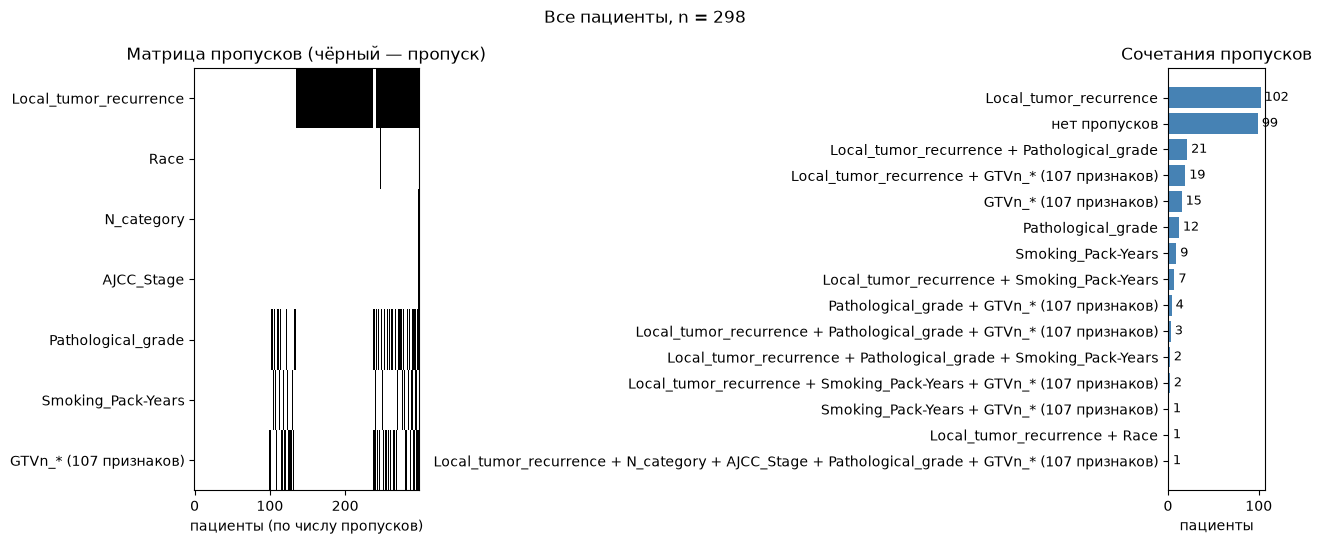

In [9]:
def plot_missing(frame, title):
    cols = frame.columns[frame.isna().any()]
    m = frame[cols].isna()
    order = m.sum(axis=1).sort_values(kind="stable").index
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 0.5 * len(cols) + 2), gridspec_kw={"width_ratios": [3, 1.3]})
    ax1.imshow(m.loc[order].T.to_numpy(), aspect="auto", cmap="Greys", interpolation="nearest")
    ax1.set_yticks(range(len(cols)), cols)
    ax1.set_xlabel("пациенты (по числу пропусков)")
    ax1.set_title("Матрица пропусков (чёрный — пропуск)")
    combos = m.apply(lambda r: " + ".join(c for c, v in r.items() if v) or "нет пропусков", axis=1).value_counts()
    ax2.barh(combos.index[::-1], combos.values[::-1], color="steelblue")
    for y, v in enumerate(combos.values[::-1]):
        ax2.text(v, y, f" {v}", va="center", fontsize=9)
    ax2.set_title("Сочетания пропусков")
    ax2.set_xlabel("пациенты")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()

plot_missing(collapse_gtvn(df[clinical_cols + ["Dose_per_fraction"] + gtvn_cols]), f"Все пациенты, n = {len(df)}")

## 3. Целевая переменная

In [10]:
df["Target_local_recurrence"] = df[TARGET_SRC].astype("Int64")
display(pd.crosstab(df.Fold, df.Target_local_recurrence.astype("string").fillna("не определён"),
                    margins=True, margins_name="всего"))

cohort = df[df.Target_local_recurrence.notna()].copy()
print(f"Исключено с неопределённым исходом: {len(df) - len(cohort)} → осталось {len(cohort)}, "
      f"доля исхода 1: {cohort.Target_local_recurrence.mean():.1%}")

Target_local_recurrence,0,1,не определён,всего
Fold,,,,
Test,0,0,158,158
Training,128,12,0,140
всего,128,12,158,298


Исключено с неопределённым исходом: 158 → осталось 140, доля исхода 1: 8.6%


,пропусков,%
GTVn_* (107 признаков),20,14.3
Pathological_grade,16,11.4
Smoking_Pack-Years,10,7.1


Переменных с пропусками > 30% (исключаются): 0


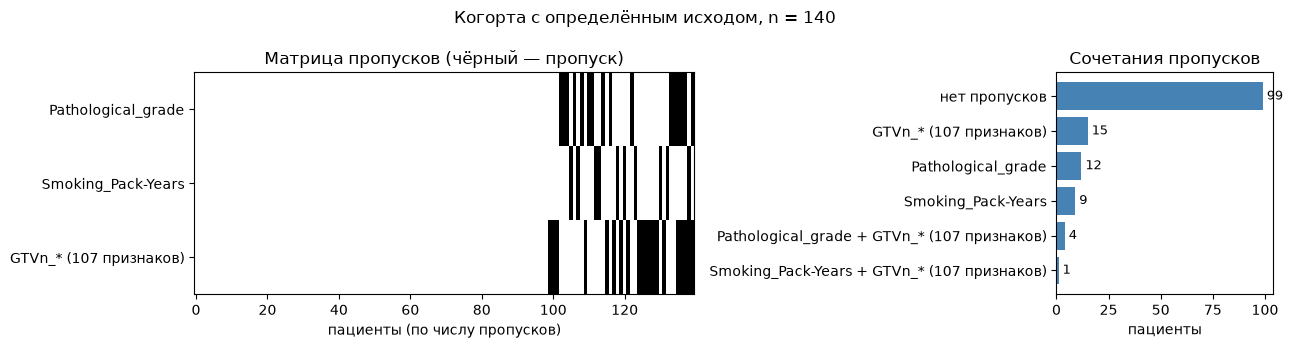

In [11]:
miss_c = missing_table(collapse_gtvn(cohort))
display(miss_c)
over = miss_c[miss_c["%"] > MISSING_SHARE_MAX * 100]
print(f"Переменных с пропусками > {MISSING_SHARE_MAX:.0%} (исключаются): {len(over)}")
plot_missing(collapse_gtvn(cohort[clinical_cols + ["Dose_per_fraction"] + gtvn_cols].drop(columns=[TARGET_SRC])),
             f"Когорта с определённым исходом, n = {len(cohort)}")

## 4. Признаки
### 4.1. Идентификатор, источник цели, недоступные в момент применения

In [12]:
excluded = {
    ID: "идентификатор (ключ строки)",
    TARGET_SRC: "источник целевой переменной",
    "Fold": "служебная (часть набора)",
    "Radiation_treatment_course_duration": "известна только после окончания ЛТ",
    "KM_Overall_survival_censor": "статус на последнем наблюдении — после момента применения",
}
display(pd.Series(excluded, name="причина исключения").to_frame())
features = [c for c in df.columns if c not in excluded and c != "Target_local_recurrence"]
print(f"Кандидатов в признаки: {len(features)}")

,причина исключения
Patient_ID,идентификатор (ключ строки)
Local_tumor_recurrence,источник целевой переменной
Fold,служебная (часть набора)
Radiation_treatment_course_duration,известна только после окончания ЛТ
KM_Overall_survival_censor,статус на последнем наблюдении — после момента применения


Кандидатов в признаки: 231


### 4.2. Константы и дубликаты (когорта n = 140)

In [13]:
nun = cohort[features].nunique(dropna=True)
constants = nun[nun <= 1].index.tolist()

dup_mask = cohort[features].T.duplicated(keep="first")
duplicates = {c: next(f for f in features if f != c and cohort[f].equals(cohort[c])) for c in dup_mask[dup_mask].index}

features = [f for f in features if f not in constants and f not in duplicates]
print(f"Констант: {len(constants)} (Fold в когорте — константа: {cohort.Fold.nunique() == 1})")
print("Дубликаты:", ", ".join(f"{c} = {t}" for c, t in duplicates.items()))
print(f"Осталось кандидатов: {len(features)}")

Констант: 0 (Fold в когорте — константа: True)
Дубликаты: GTVp_firstorder_TotalEnergy = GTVp_firstorder_Energy, GTVn_firstorder_TotalEnergy = GTVn_firstorder_Energy
Осталось кандидатов: 229


### 4.3. Сокращение избыточных количественных признаков

In [14]:
quant_clin = ["Age_at_diagnosis", "Smoking_Pack-Years", "Total_prescribed_Radiation_treatment_dose",
              "Dose_per_fraction", "#_Radiation_treatment_fractions"]
cls_order = ["shape", "firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]
def roi_order(prefix):
    first = [f"{prefix}_shape_MeshVolume", f"{prefix}_shape_Sphericity"]
    rad = [f for f in features if f.startswith(prefix + "_") and f != "GTVn_n_nodes"]
    return first + sorted([f for f in rad if f not in first],
                          key=lambda f: (cls_order.index(f.split("_")[1]), rad.index(f)))

order = [f for f in quant_clin if f in features] + roi_order("GTVp") + ["GTVn_n_nodes"] + roi_order("GTVn")

rho = cohort[order].corr(method="spearman").abs()
kept, replaced_by = [], {}
for f in order:
    hit = [k for k in kept if rho.loc[f, k] > CORR_THRESHOLD]
    if hit:
        replaced_by[f] = max(hit, key=lambda k: rho.loc[f, k])
    else:
        kept.append(f)

def root(f):
    f = duplicates.get(f, f)
    while f in replaced_by:
        f = replaced_by[f]
    return f

absorbed = pd.Series([root(f) for f in list(replaced_by) + list(duplicates)]).value_counts()
summary = pd.DataFrame({
    "заменяет": [int(absorbed.get(k, 0)) for k in kept],
    "исключённые признаки": [", ".join(f for f in list(replaced_by) + list(duplicates)
                                       if root(f) == k) for k in kept]},
    index=pd.Index(kept, name="оставлен"))
print(f"Вход: {len(order)} признаков ({len(quant_clin)} клинических, GTVn_n_nodes, "
      f"{sum(f.startswith('GTVp_') for f in order)} GTVp, {sum(f.startswith('GTVn_') for f in order) - 1} GTVn), порог |rho Спирмена| > {CORR_THRESHOLD} → оставлено {len(kept)}, "
      f"исключено {len(replaced_by)}, дубликатов {len(duplicates)}")
cross = sum(f[:4] != root(f)[:4] for f in replaced_by if f.startswith("GTV") and root(f).startswith("GTV"))
print(f"Пациентов с узлами в когорте (n для корреляций GTVn): {int(cohort.GTVn_shape_MeshVolume.notna().sum())}; "
      f"замен между масками GTVp и GTVn: {cross}")
with pd.option_context("display.max_rows", 150):
    display(summary)

Вход: 218 признаков (5 клинических, GTVn_n_nodes, 106 GTVp, 106 GTVn), порог |rho Спирмена| > 0.9 → оставлено 91, исключено 127, дубликатов 2
Пациентов с узлами в когорте (n для корреляций GTVn): 120; замен между масками GTVp и GTVn: 0


,заменяет,исключённые признаки
оставлен,,
Age_at_diagnosis,0,
Smoking_Pack-Years,0,
Total_prescribed_Radiation_treatment_dose,0,
Dose_per_fraction,1,#_Radiation_treatment_fractions
GTVp_shape_MeshVolume,13,"GTVp_shape_LeastAxisLength, GTVp_shape_MinorAxisLength, GTVp_shape_SurfaceArea, GTVp_shape_VoxelVolume, GTVp_firstor..."
GTVp_shape_Sphericity,0,
GTVp_shape_Elongation,0,
GTVp_shape_Flatness,0,
GTVp_shape_MajorAxisLength,3,"GTVp_shape_Maximum2DDiameterColumn, GTVp_shape_Maximum2DDiameterRow, GTVp_shape_Maximum3DDiameter"


Максимальная |rho| среди оставленных: 0.8999 (GTVp_firstorder_Minimum — GTVp_glrlm_LongRunLowGrayLevelEmphasis); пар выше порога: 0


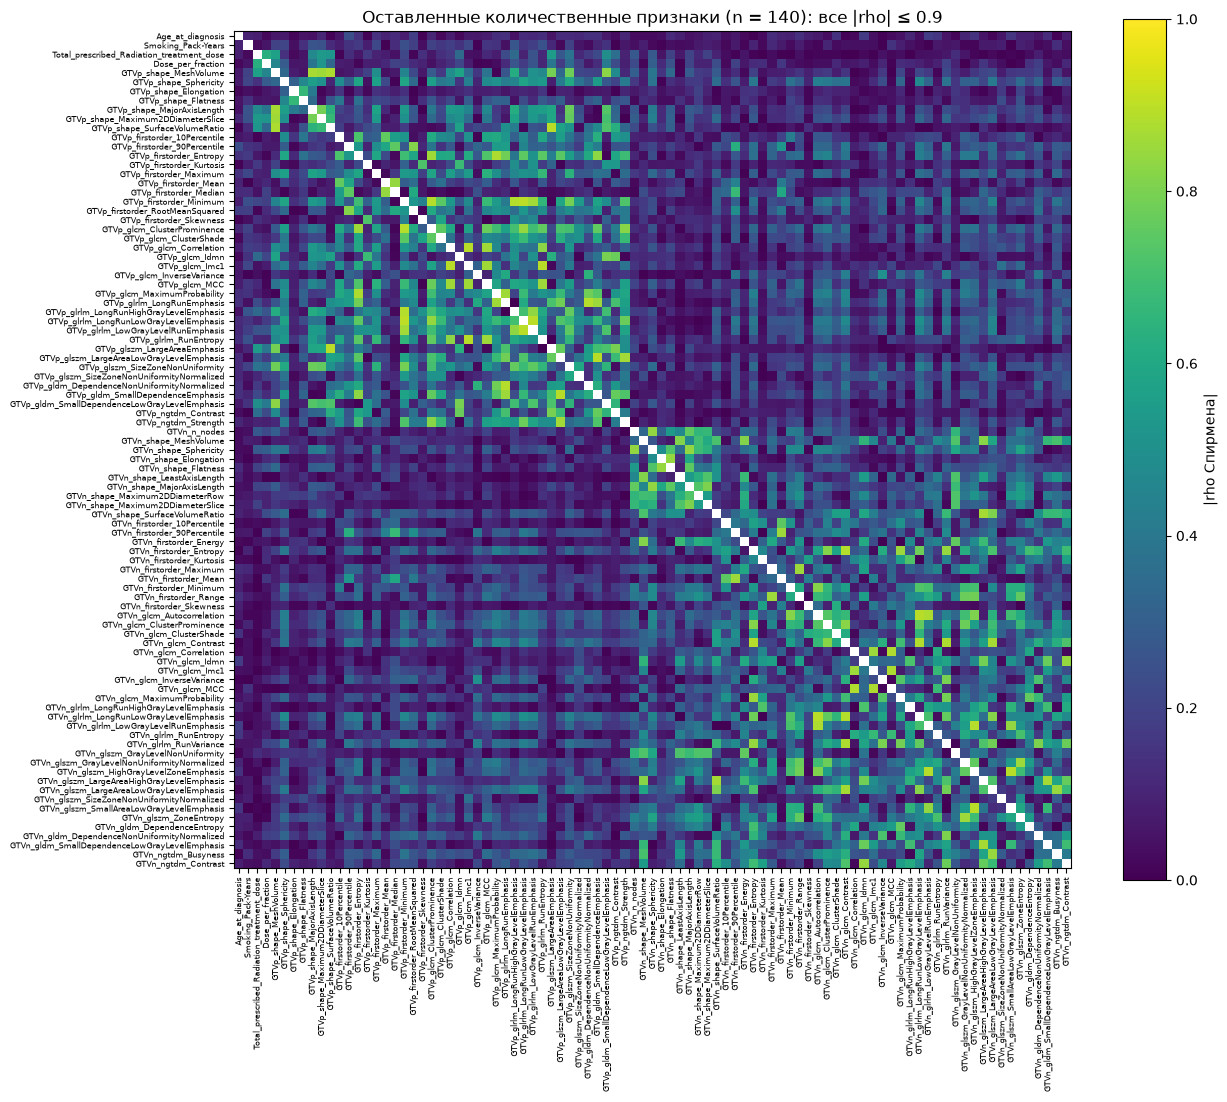

In [15]:
r_kept = cohort[kept].corr(method="spearman").abs()
r_kept = r_kept.mask(np.eye(len(kept), dtype=bool))
i, j = np.unravel_index(np.nanargmax(r_kept.values), r_kept.shape)
assert np.nanmax(r_kept.values) <= CORR_THRESHOLD
print(f"Максимальная |rho| среди оставленных: {r_kept.values[i, j]:.4f} ({kept[i]} — {kept[j]}); "
      f"пар выше порога: {int((r_kept.values > CORR_THRESHOLD).sum() // 2)}")

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(r_kept, vmin=0, vmax=1, cmap="viridis")
short = kept
ax.set_xticks(range(len(kept)), short, rotation=90, fontsize=6)
ax.set_yticks(range(len(kept)), short, fontsize=6)
fig.colorbar(im, ax=ax, label="|rho Спирмена|")
ax.set_title(f"Оставленные количественные признаки (n = {len(cohort)}): все |rho| ≤ {CORR_THRESHOLD}")
fig.tight_layout()
plt.show()

## 5. Аналитическая таблица

In [16]:
cat_features = [f for f in features if f not in order]
final_features = cat_features + kept
analytic = cohort[[ID, "Target_local_recurrence"] + final_features].sort_values(ID).reset_index(drop=True)
assert analytic[ID].is_unique and analytic.Target_local_recurrence.notna().all()
analytic.to_csv(OUT_CSV, index=False)

check = pd.read_csv(OUT_CSV)
n_p = sum(k.startswith("GTVp_") for k in kept)
n_n = sum(k.startswith("GTVn_") and k != "GTVn_n_nodes" for k in kept)
print(f"{OUT_CSV}: {len(check)} пациентов × {check.shape[1]} столбцов (код, цель и признаки — {check.shape[1] - 2}: "
      f"{len(cat_features)} категориальных + {len(kept) - n_p - n_n} количественных клинических, включая GTVn_n_nodes, "
      f"+ {n_p} GTVp + {n_n} GTVn)")
print(f"Исход 1/0: {int(check.Target_local_recurrence.sum())}/{int((check.Target_local_recurrence == 0).sum())}; "
      f"пропусков (не заполнялись): {int(check.isna().sum().sum())}, "
      f"из них в GTVn: {int(check.filter(like='GTVn_').isna().sum().sum())}")

analytic_table.csv: 140 пациентов × 104 столбцов (код, цель и признаки — 102: 11 категориальных + 5 количественных клинических, включая GTVn_n_nodes, + 39 GTVp + 47 GTVn)
Исход 1/0: 12/128; пропусков (не заполнялись): 966, из них в GTVn: 940


## 6. Сводка для словаря переменных

In [17]:
rows = clinical_cols + ["GTVn_n_nodes", "Dose_per_fraction", "Target_local_recurrence"] + \
       [k for k in kept if k.startswith(("GTVp_", "GTVn_")) and k != "GTVn_n_nodes"]
def decision(c):
    if c in excluded:
        return "исключена"
    if c == "Target_local_recurrence":
        return "целевая"
    return "признак" if c in final_features else "исключена (избыточность)"

dict_summary = pd.DataFrame({
    "пропуски (298)": [int(df[c].isna().sum()) for c in rows],
    "пропуски (140)": [int(cohort[c].isna().sum()) for c in rows],
    "решение": [decision(c) for c in rows],
    "заменяет": [int(absorbed.get(c, 0)) if c in kept else "" for c in rows],
}, index=rows)
with pd.option_context("display.max_rows", 150):
    display(dict_summary)

,пропуски (298),пропуски (140),решение,заменяет
Patient_ID,0,0,исключена,
Fold,0,0,исключена,
Local_tumor_recurrence,158,0,исключена,
Gender,0,0,признак,
Age_at_diagnosis,0,0,признак,0
Race,1,0,признак,
Tumor_side,0,0,признак,
Tumor_subsite,0,0,признак,
T_category,0,0,признак,
N_category,1,0,признак,
